In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
c1 = pd.read_csv('../data/pOXA48/plate_counts.tsv', sep='\t')
c2 = pd.read_csv('../data/PN23/plate_counts.tsv', sep='\t')

m1 = pd.read_csv('../data/pOXA48/chibio.tsv.gz', sep='\t')
m2 = pd.read_csv('../data/PN23/chibio.tsv.gz', sep='\t')

f1 = pd.read_csv('../data/pOXA48/flow_cytometer.tsv', sep='\t')
f2 = pd.read_csv('../data/PN23/flow_cytometer.tsv', sep='\t')

res = []
for df1, df2 in zip([c1, m1, f1], [c2, m2, f2]):
    df1['replicate'] = df1['replicate'].astype(str).str.replace('rep', '')
    df2['replicate'] = df2['replicate'].astype(str).str.replace('rep', '')

    df1 = df1[~((df1['vial'] == 'M0') &
                (df1['replicate'] == '1'))].reset_index(drop=True)

    df1['exp'] = 'AMP'
    df2['exp'] = 'COL'

    df1a = df1[df1['short'] == 'KAN no drug']
    df1b = df1[(df1['short'] == 'PVB no drug') &
               (df1['replicate'] == '2')]
    df2a = df2[(df2['short'] == 'PN23 no drug') &
               (df2['replicate'] == '2')]
    df2b = df2[(df2['short'] == 'KAN 1xMIC') &
               (df2['replicate'] == '2')]

    df = pd.concat([df1a, df1b,
                    df2a, df2b],
                   axis=0).reset_index(drop=True)
    res.append(df)

c, m, f = res

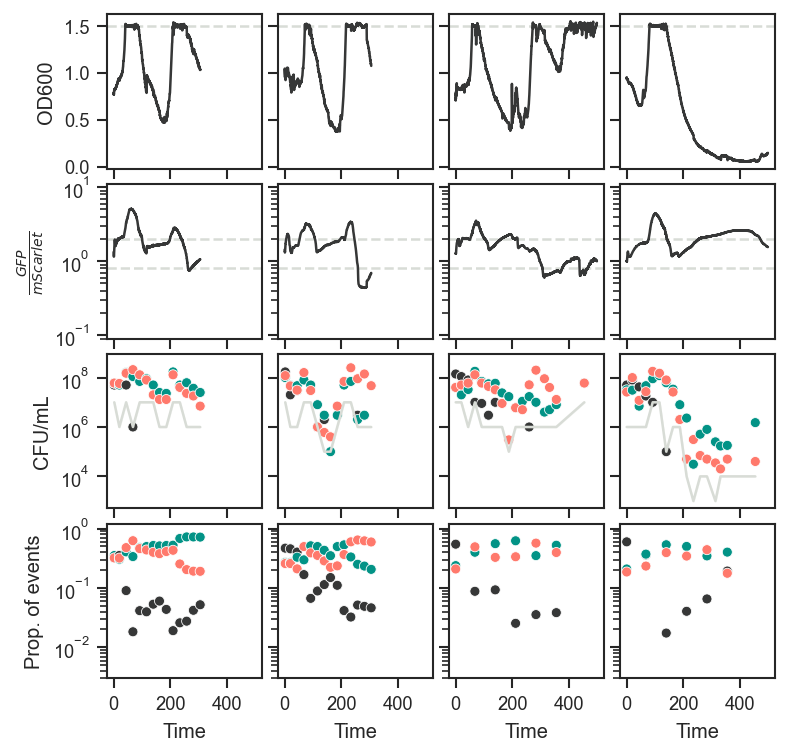

In [4]:
col_order = ['KAN no drug', 'PVB no drug', 'PN23 no drug', 'KAN 1xMIC']
hue_order = ['PL', 'PM', 'LM']
palette = ['xkcd:teal', 'xkcd:salmon', 'xkcd:dark grey']

row_labels = ['OD650', r'$\frac{GFP}{mScarlet}$',
              'CFU/mL', 'Prop. of events']

fig, axes = plt.subplots(4, len(col_order),
                         figsize=(5.75, 5.75),
                         sharex=True, sharey='row')

for j, short in enumerate(col_order):
    sns.lineplot(data=m[m['short'] == short],
                 x='time', y='smooth_od', ax=axes[0, j],
                 color='xkcd:dark grey')
    axes[0, j].axhline(1.5, color='xkcd:light grey', ls='--',
                       zorder=-1)

    sns.lineplot(data=m[m['short'] == short],
                 x='time', y='smooth_FP1_emit1_FP2_emit1_ratio',
                 color='xkcd:dark grey',
                 ax=axes[1, j])
    axes[1, j].set_yscale('log')
    axes[1, j].set_ylim(0.09, 11)
    axes[1, j].axhline(0.8, color='xkcd:light grey', ls='--',
                       zorder=-1)
    axes[1, j].axhline(2, color='xkcd:light grey', ls='--',
                       zorder=-1)
    
    sns.scatterplot(data=c[(c['plate'] == 'KAN') & (c['short'] == short)],
                    x='time', y='CFU/mL',
                    hue='strain', hue_order=hue_order, palette=palette,
                    ax=axes[2, j],
                    legend=False)
    sns.lineplot(data=c[(c['plate'] == 'KAN') & (c['short'] == short)],
                 x='time', y='detection_limit',
                 color='xkcd:light grey',
                 ax=axes[2, j],
                 legend=False)
    
    axes[2, j].set_yscale('log')
    axes[2, j].set_ylim(500, 9E8)

    sns.scatterplot(data=f[f['short'] == short],
                    x='time', y='proportion',
                    hue='strain', hue_order=hue_order, palette=palette,
                    ax=axes[3, j], legend=False)
    axes[3, j].set_yscale('log')
    axes[3, j].set_ylim(0.003, 1.2)

    # axes[0, j].set_title(short)

    for i in range(4):
        axes[i, j].set_ylabel(row_labels[i] if j == 0 else '')
        axes[i, j].set_xlabel('Time' if i == 3 else '')
        axes[i, j].set_xlim(-25, 525)
        axes[i, j].set_xticks([0, 200, 400,])

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('community_dynamics.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('community_dynamics.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);